In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp
from jax.scipy.spatial.transform import Rotation as Rot



import genmetaballs.fmb.fm_render as fm_render
from genmetaballs.core import (
    FMB,
    Intrinsics,
    ThreeParameterBlender,
    ZeroParameterConfidence,
    geometry,
    make_fmb_scene_from_values,
    render_fmbs,
)
from genmetaballs.fmb.utils import DegradeLR, get_camera_rays, image_grid

Pose, Vec3D, Rotation = geometry.Pose, geometry.Vec3D, geometry.Rotation


# JAX setup (before importing)
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
np.random.seed(0)
print(f"JAX version: {jax.__version__}")
print(f"JAX backend: {jax.default_backend().upper()}")
print(f"JAX devices: {jax.devices()}")

Running cmake --build & --install in /home/matin/GenMetaBalls/build
JAX version: 0.8.0
JAX backend: GPU
JAX devices: [CudaDevice(id=0)]


In [2]:
image_size = (64, 64)
focal_length = 1.0
cx = (image_size[1] - 1) / 2
cy = (image_size[0] - 1) / 2

In [3]:
NUM_MIXTURE = 40
hyperparams = fm_render.hyperparams
beta2 = jnp.float32(np.exp(hyperparams[0]))
beta3 = jnp.float32(np.exp(hyperparams[1]))

In [4]:
# Initialize random Gaussian cloud
means = np.random.multivariate_normal(
    mean=[0, 0, 0], cov=2e-2 * np.identity(3), size=NUM_MIXTURE
)
log_weights = jnp.log(np.ones(NUM_MIXTURE) / NUM_MIXTURE)
precs = jnp.array([np.identity(3) * 10] * NUM_MIXTURE)

# Setup camera rays
height, width = image_size
pixel_list = (
    (np.array(np.meshgrid(np.arange(width), height - np.arange(height) - 1, [0]))[:, :, :, 0])
    .reshape((3, -1))
    .T
)
camera_rays = get_camera_rays(focal_length, focal_length, cx, cy, pixel_list)
rays_trans = np.stack(
    [camera_rays, np.tile(np.zeros(3), (camera_rays.shape[0], 1))], 1
)

In [5]:
# JIT compile render function
render_jit = jax.jit(fm_render.render_func_rays)


est_depth, est_alpha, est_norm, est_w = render_jit(
    means, precs, log_weights, rays_trans, beta2, beta3
)

In [6]:
@jax.jit
def cov_to_isostds_and_quaternion(cov):
    """
    Convert a 3D Gaussian's covariance matrix to an isotropic stds vector and a rotation quaternion.

    Args:
    - cov: (3, 3) covariance matrix

    Returns:
    - vars: (3,) array of isotropic variances
    - quat: (4,) quaternion
    """
    eigvals, eigvecs = jnp.linalg.eigh(cov)

    # Ensure positive eigenvalues (numerical stability)
    vars = jnp.maximum(eigvals, 0)

    # Ensure deterministic eigenvector orientation
    for i in range(3):
        eigvecs = eigvecs.at[:, i].set(jnp.where(eigvecs[0, i] < 0, -eigvecs[:, i], eigvecs[:, i]))

    # Ensure proper rotation matrix (determinant +1)
    eigvecs = eigvecs.at[:, 0].set(
        jnp.where(jnp.linalg.det(eigvecs) < 0, -eigvecs[:, 0], eigvecs[:, 0])
    )

    # Convert rotation matrix to quaternion
    quat = Rot.from_matrix(eigvecs).as_quat()

    return jnp.sqrt(vars), quat

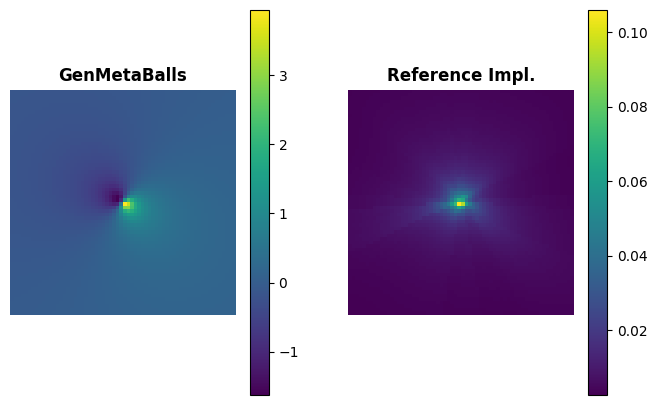

In [7]:
fmbs = []
for i in range(NUM_MIXTURE):
    stds, quat = cov_to_isostds_and_quaternion(jnp.linalg.inv(precs[i]))
    pose = Pose.from_components(Rotation.from_quat(*quat), Vec3D(*means[i]))
    fmbs.append(FMB(pose, *stds))

scene = make_fmb_scene_from_values(fmbs, list(log_weights), device="gpu")


confidence = ZeroParameterConfidence()
blender = ThreeParameterBlender(beta1=beta3, beta2=beta2, eta=1.0)

camera = Intrinsics(fx=focal_length, fy=focal_length, cx=cx, cy=cy, width=width, height=height)
pose = geometry.Pose()
image = render_fmbs(scene, blender, confidence, camera, pose)
img_view = image.as_view()

depth_image = img_view.depth.as_jax()
confidence = img_view.confidence.as_jax()

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(8, 5))
im0 = ax0.imshow(depth_image)
ax0.set_title("GenMetaBalls", fontsize=12, fontweight="bold")
ax0.axis("off")
plt.colorbar(im0, ax=ax0)

ax1.set_title("Reference Impl.", fontsize=12, fontweight="bold")
im1 = ax1.imshow(est_depth.reshape(image_size))
ax1.axis("off")
plt.colorbar(im1, ax=ax1)